# Partial Dependence for 2 Features Explainer Demo

This example demonstrates how to interpret a model using the H2O Sonar library and retrieve the data and **partial dependence plot for 2 featues**.

In [1]:
import logging
import os

import daimojo
import datatable
import webbrowser

from h2o_sonar import interpret
from h2o_sonar.lib.api import commons, explainers
from h2o_sonar.lib.api.models import ModelApi
from h2o_sonar.explainers.pd_2_features_explainer import PdFor2FeaturesExplainer

In [2]:
# dataset
dataset_path = "../../data/predictive/creditcard.csv"
target_col = "default payment next month"

# model
mojo_path = "../../data/predictive/models/creditcard-binomial.mojo"
mojo_model = daimojo.model(mojo_path)
model = ModelApi().create_model(
    model_src=mojo_model,
    target_col=target_col,
    used_features=list(mojo_model.feature_names),
)

# results
results_location = "./results"
os.makedirs(results_location, exist_ok=True)

In [3]:
# explainer description
interpret.describe_explainer(PdFor2FeaturesExplainer)

{'id': 'h2o_sonar.explainers.pd_2_features_explainer.PdFor2FeaturesExplainer',
 'name': 'PdFor2FeaturesExplainer',
 'display_name': 'Partial Dependence Plot for Two Features',
 'tagline': 'PdFor2FeaturesExplainer.',
 'description': 'Partial dependence for 2 features portrays the average\nprediction behavior of a model across the domains of two input variables\ni.e. interaction of feature tuples with the prediction. While PD for one feature\nproduces 2D plot, PD for two features produces 3D plots. This explainer plots PD for\ntwo features using heatmap, contour 3D or surface 3D.\n',
 'brief_description': 'PdFor2FeaturesExplainer.',
 'model_types': ['iid', 'time_series'],
 'can_explain': ['regression', 'binomial'],
 'explanation_scopes': ['global_scope'],
 'explanations': [{'explanation_type': 'global-partial-dependence',
   'name': 'PartialDependenceExplanation',
   'category': '',
   'scope': 'global',
   'has_local': '',
   'formats': []}],
 'keywords': ['is_slow'],
 'parameters': [{'

## Interpretation

In [4]:
interpretation = interpret.run_interpretation(
    dataset=dataset_path,
    model=model,
    target_col=target_col,
    results_location=results_location,
    log_level=logging.INFO,
    explainers=[
        commons.ExplainerToRun(
            explainer_id=PdFor2FeaturesExplainer.explainer_id(),
            params="",
        )
    ]
)

/home/user/h/mli/git/h2o-sonar-FLOSS/.venv/lib/python3.11/site-packages/ragas/metrics/__init__.py:1: LangChainDeprecationWarning: As of langchain-core 0.3.0, LangChain uses pydantic v2 internally. The langchain_core.pydantic_v1 module was a compatibility shim for pydantic v1, and should no longer be used. Please update the code to import from Pydantic directly.

For example, replace imports like: `from langchain_core.pydantic_v1 import BaseModel`
with: `from pydantic import BaseModel`
or the v1 compatibility namespace if you are working in a code base that has not been fully upgraded to pydantic 2 yet. 	from pydantic.v1 import BaseModel

  from ragas.metrics._answer_correctness import AnswerCorrectness, answer_correctness
/home/user/h/mli/git/h2o-sonar-FLOSS/.venv/lib/python3.11/site-packages/ragas/metrics/__init__.py:4: LangChainDeprecationWarning: As of langchain-core 0.3.0, LangChain uses pydantic v2 internally. The langchain.pydantic_v1 module was a compatibility shim for pydantic 

## Explainer Result

In [5]:
# retrieve the result
result = interpretation.get_explainer_result(PdFor2FeaturesExplainer.explainer_id())

In [6]:
# open interpretation HTML report in web browser
webbrowser.open(interpretation.result.get_html_report_location())

True

In [7]:
# summary
result.summary()

{'id': 'h2o_sonar.explainers.pd_2_features_explainer.PdFor2FeaturesExplainer',
 'name': 'PdFor2FeaturesExplainer',
 'display_name': 'Partial Dependence Plot for Two Features',
 'tagline': 'PdFor2FeaturesExplainer.',
 'description': 'Partial dependence for 2 features portrays the average\nprediction behavior of a model across the domains of two input variables\ni.e. interaction of feature tuples with the prediction. While PD for one feature\nproduces 2D plot, PD for two features produces 3D plots. This explainer plots PD for\ntwo features using heatmap, contour 3D or surface 3D.\n',
 'brief_description': 'PdFor2FeaturesExplainer.',
 'model_types': ['iid', 'time_series'],
 'can_explain': ['regression', 'binomial'],
 'explanation_scopes': ['global_scope'],
 'explanations': [{'explanation_type': 'global-report',
   'name': 'Partial Dependence Plot for Two Features',
   'category': 'DAI MODEL',
   'scope': 'global',
   'has_local': None,
   'formats': ['text/markdown']},
  {'explanation_typ

In [8]:
# parameters
result.params()

{'sample_size': 25000,
 'max_features': 3,
 'features': None,
 'grid_resolution': 10,
 'oor_grid_resolution': 0,
 'quantile-bin-grid-resolution': 0,
 'plot_type': 'heatmap'}

### Display PD Data

In [9]:
result.data(feature_names="'LIMIT_BAL' and 'EDUCATION'")

{'10000': {'6': 0.2552240192890167,
  '5': 0.2552240192890167,
  '4': 0.25266972184181213,
  '3': 0.25266972184181213,
  '2': 0.2251938432455063,
  '1': 0.2251938432455063,
  '0': 0.2251938432455063},
 '208000': {'6': 0.21158096194267273,
  '5': 0.21158096194267273,
  '4': 0.20898468792438507,
  '3': 0.20898468792438507,
  '2': 0.17519091069698334,
  '1': 0.17519091069698334,
  '0': 0.17519091069698334},
 '307000': {'6': 0.20750007033348083,
  '5': 0.20750007033348083,
  '4': 0.20484082400798798,
  '3': 0.20484082400798798,
  '2': 0.17081709206104279,
  '1': 0.17081709206104279,
  '0': 0.17081709206104279},
 '406000': {'6': 0.20645806193351746,
  '5': 0.20645806193351746,
  '4': 0.2037988305091858,
  '3': 0.2037988305091858,
  '2': 0.17081709206104279,
  '1': 0.17081709206104279,
  '0': 0.17081709206104279},
 '505000': {'6': 0.20645806193351746,
  '5': 0.20645806193351746,
  '4': 0.2037988305091858,
  '3': 0.2037988305091858,
  '2': 0.17081709206104279,
  '1': 0.17081709206104279,
  '0

### Plot PD Data

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.


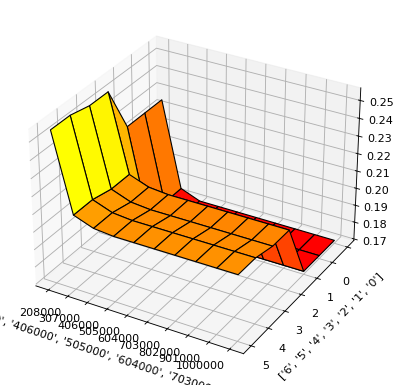

In [10]:
result.plot(feature_names="'LIMIT_BAL' and 'EDUCATION'")

### Save Explainer Log and Data

In [11]:
# save the explainer log
result.log(path="./pd-2-features-demo.log")

In [12]:
!head pd-ice-demo.log

2026-01-29 16:11:38,082 INFO PD/ICE ea8d1116-5f12-4d93-b0c6-91453d509ffd/cba719fb-5061-483d-add5-79c4175d2b25 BEGIN calculation
2026-01-29 16:11:38,082 INFO PD/ICE ea8d1116-5f12-4d93-b0c6-91453d509ffd/cba719fb-5061-483d-add5-79c4175d2b25 loading dataset
2026-01-29 16:11:38,082 INFO PD/ICE ea8d1116-5f12-4d93-b0c6-91453d509ffd/cba719fb-5061-483d-add5-79c4175d2b25 loaded dataset has 10000 rows and 25 columns
2026-01-29 16:11:38,082 INFO PD/ICE ea8d1116-5f12-4d93-b0c6-91453d509ffd/cba719fb-5061-483d-add5-79c4175d2b25 getting features list, importance and metadata
2026-01-29 16:11:38,082 INFO PD/ICE ea8d1116-5f12-4d93-b0c6-91453d509ffd/cba719fb-5061-483d-add5-79c4175d2b25 all most important model features: ['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']
2026-01-29 16:11:38,082 IN

In [13]:
# save the explainer data
result.zip(file_path="./pd-ice-demo-archive.zip")

In [14]:
!unzip -l pd-ice-demo-archive.zip

Archive:  pd-ice-demo-archive.zip
  Length      Date    Time    Name
---------  ---------- -----   ----
     4617  2026-01-29 16:22   explainer_h2o_sonar_explainers_pd_2_features_explainer_PdFor2FeaturesExplainer_c1f2af1f-eb25-42cc-9fad-d0290c557dce/result_descriptor.json
        2  2026-01-29 16:22   explainer_h2o_sonar_explainers_pd_2_features_explainer_PdFor2FeaturesExplainer_c1f2af1f-eb25-42cc-9fad-d0290c557dce/problems/problems_and_actions.json
      110  2026-01-29 16:22   explainer_h2o_sonar_explainers_pd_2_features_explainer_PdFor2FeaturesExplainer_c1f2af1f-eb25-42cc-9fad-d0290c557dce/global_html_fragment/text_html.meta
    80253  2026-01-29 16:22   explainer_h2o_sonar_explainers_pd_2_features_explainer_PdFor2FeaturesExplainer_c1f2af1f-eb25-42cc-9fad-d0290c557dce/global_html_fragment/text_html/image-2.png
     1247  2026-01-29 16:22   explainer_h2o_sonar_explainers_pd_2_features_explainer_PdFor2FeaturesExplainer_c1f2af1f-eb25-42cc-9fad-d0290c557dce/global_html_fragment/text_htm